# Exploratory Data Analysis - Công Thức Nấu Ăn (Dữ Liệu Đã Xử Lý)
Phân tích dữ liệu các công thức nấu ăn từ DienmayXanh sau khi loại bỏ placeholder ingredients

## Khai báo thư viện 

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

In [2]:
df_urls = pd.read_csv('recipe_urls.csv')

with open('unique_ingredients.json', 'r', encoding='utf-8') as f:
    unique_ingredients = json.load(f)

with open('unique_dishes.json', 'r', encoding='utf-8') as f:
    unique_dishes = json.load(f)



with open('recipes_processed.json', 'r', encoding='utf-8') as f:
    recipes_data = json.load(f)

df_recipes = pd.DataFrame(recipes_data)

print("Dữ liệu đã được tải thành công (DỮ LIỆU ĐÃ XỬ LÝ)")
print(f"Số tệp URL: {len(df_urls)}")
print(f"Số công thức nấu: {len(df_recipes)}")
print(f"Số nguyên liệu duy nhất: {len(unique_ingredients)}")
print(f"Số món ăn duy nhất: {len(unique_dishes)}")

Dữ liệu đã được tải thành công (DỮ LIỆU ĐÃ XỬ LÝ)
Số tệp URL: 14502
Số công thức nấu: 10253
Số nguyên liệu duy nhất: 7947
Số món ăn duy nhất: 10012


## Tổng Quan Tập Dữ Liệu

In [3]:
print("THỐNG KÊ TỔNG QUÁT")

print(f"\nFile URLs:")
print(f"  - Số dòng: {len(df_urls)}")
print(f"  - Số cột: {df_urls.shape[1]}")
print(f"  - Tên cột: {list(df_urls.columns)}")

print(f"\nFile Recipes Detail:")
print(f"  - Số công thức: {len(df_recipes)}")
print(f"  - Các trường trong mỗi công thức: {list(df_recipes.columns)}")

print(f"\nFile Unique Ingredients:")
print(f"  - Tổng số nguyên liệu: {len(unique_ingredients)}")
print(f"  - Loại dữ liệu: {type(unique_ingredients)}")

print(f"\nFile Unique Dishes:")
print(f"  - Tổng số món ăn: {len(unique_dishes)}")
print(f"  - Loại dữ liệu: {type(unique_dishes)}")



THỐNG KÊ TỔNG QUÁT

File URLs:
  - Số dòng: 14502
  - Số cột: 2
  - Tên cột: ['category', 'url']

File Recipes Detail:
  - Số công thức: 10253
  - Các trường trong mỗi công thức: ['dish_name', 'url', 'difficulty', 'views', 'ingredients', 'instructions', 'category', 'prep_time_min', 'cook_time_min', 'servings_bin', 'cook_time_source', 'popularity']

File Unique Ingredients:
  - Tổng số nguyên liệu: 7947
  - Loại dữ liệu: <class 'list'>

File Unique Dishes:
  - Tổng số món ăn: 10012
  - Loại dữ liệu: <class 'list'>


## Phân Tích Chi Tiết Dữ Liệu Recipes

In [4]:
print(f"\nKích thước: {df_recipes.shape[0]} hàng x {df_recipes.shape[1]} cột")
print(f"\nTên các cột:")
for i, col in enumerate(df_recipes.columns, 1):
    print(f"  {i}. {col}")

print(f"\nDữ liệu thiếu:")
missing = df_recipes.isnull().sum()
missing_percent = (df_recipes.isnull().sum() / len(df_recipes)) * 100
for col in df_recipes.columns:
    print(f"  {col}: {missing[col]} ({missing_percent[col]:.2f}%)")

print(f"\nKiểu dữ liệu các cột:")
print(df_recipes.dtypes)

print(f"\nMột số dòng dữ liệu mẫu:")
df_recipes.head(3)


Kích thước: 10253 hàng x 12 cột

Tên các cột:
  1. dish_name
  2. url
  3. difficulty
  4. views
  5. ingredients
  6. instructions
  7. category
  8. prep_time_min
  9. cook_time_min
  10. servings_bin
  11. cook_time_source
  12. popularity

Dữ liệu thiếu:
  dish_name: 0 (0.00%)
  url: 0 (0.00%)
  difficulty: 0 (0.00%)
  views: 0 (0.00%)
  ingredients: 0 (0.00%)
  instructions: 0 (0.00%)
  category: 0 (0.00%)
  prep_time_min: 0 (0.00%)
  cook_time_min: 0 (0.00%)
  servings_bin: 0 (0.00%)
  cook_time_source: 0 (0.00%)
  popularity: 0 (0.00%)

Kiểu dữ liệu các cột:
dish_name           object
url                 object
difficulty           int64
views                int64
ingredients         object
instructions        object
category            object
prep_time_min        int64
cook_time_min        int64
servings_bin        object
cook_time_source    object
popularity          object
dtype: object

Một số dòng dữ liệu mẫu:


,dish_name,url,difficulty,views,ingredients,instructions,category,prep_time_min,cook_time_min,servings_bin,cook_time_source,popularity
0,Vịt quay tỳ bà,https://www.dienmayxanh.com/vao-bep/cach-lam-v...,3,16,"[{'name': 'Vịt', 'quantity': 1.0, 'unit': 'con...","[{'step_title': 'Sơ chế và lọc xương vịt', 'co...",Món nướng,600,25,4-6 người,original,Rất thấp
1,Dẻ sườn bò nướng sa tế,https://www.dienmayxanh.com/vao-bep/cong-thuc-...,1,1,"[{'name': 'Dẻ sườn bò', 'quantity': 500.0, 'un...","[{'step_title': 'Sơ chế và phi thơm hành tỏi',...","[Món nướng, Món từ bò]",20,80,2-3 người,original,Rất thấp
2,thịt heo quay tại nhà,https://www.dienmayxanh.com/vao-bep/cach-lam-t...,2,1,"[{'name': 'Thịt ba rọi', 'quantity': 800.0, 'u...","[{'step_title': 'Sơ chế thịt ba rọi', 'content...",Món nướng,25,60,Uncertain,original,Rất thấp


### Thống Kê Mô Tả cho Các Biến Số

In [5]:
numeric_cols = df_recipes.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print("\n" + "=" * 60)
    print("THỐNG KÊ CÁC BIẾN SỐ")
    print("=" * 60)
    
    stats_df = df_recipes[numeric_cols].describe().T
    stats_df.columns = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
    
    print("\nThống kê cơ bản (Mean, Median, Std, Min, Max):")
    print(stats_df.to_string())
    
    print("\n\nPhương sai (Variance):")
    for col in numeric_cols:
        variance = df_recipes[col].var()
        print(f"  {col}: {variance:.4f}")
    
    print("\n\nKhoảng tứ phân vị (IQR):")
    for col in numeric_cols:
        q1 = df_recipes[col].quantile(0.25)
        q3 = df_recipes[col].quantile(0.75)
        iqr = q3 - q1
        print(f"  {col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
else:
    print("Không có biến số trong cột, hoặc tất cả các cột là chuỗi ký tự")


THỐNG KÊ CÁC BIẾN SỐ

Thống kê cơ bản (Mean, Median, Std, Min, Max):
                 Count          Mean           Std  Min     25%     50%      75%        Max
difficulty     10253.0      1.127572      0.341718  1.0     1.0     1.0      1.0        3.0
views          10253.0  21947.902175  56173.275293  0.0  2105.0  6583.0  18983.0  1331941.0
prep_time_min  10253.0     32.948698     69.430607  1.0    15.0    20.0     30.0     1380.0
cook_time_min  10253.0     45.103970    675.310858  0.0    15.0    25.0     40.0    64800.0


Phương sai (Variance):
  difficulty: 0.1168
  views: 3155436857.1047
  prep_time_min: 4820.6092
  cook_time_min: 456044.7545


Khoảng tứ phân vị (IQR):
  difficulty: Q1=1.00, Q3=1.00, IQR=0.00
  views: Q1=2105.00, Q3=18983.00, IQR=16878.00
  prep_time_min: Q1=15.00, Q3=30.00, IQR=15.00
  cook_time_min: Q1=15.00, Q3=40.00, IQR=25.00


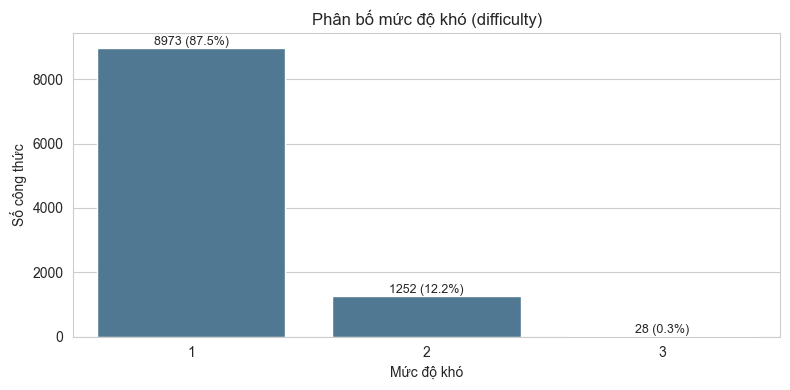

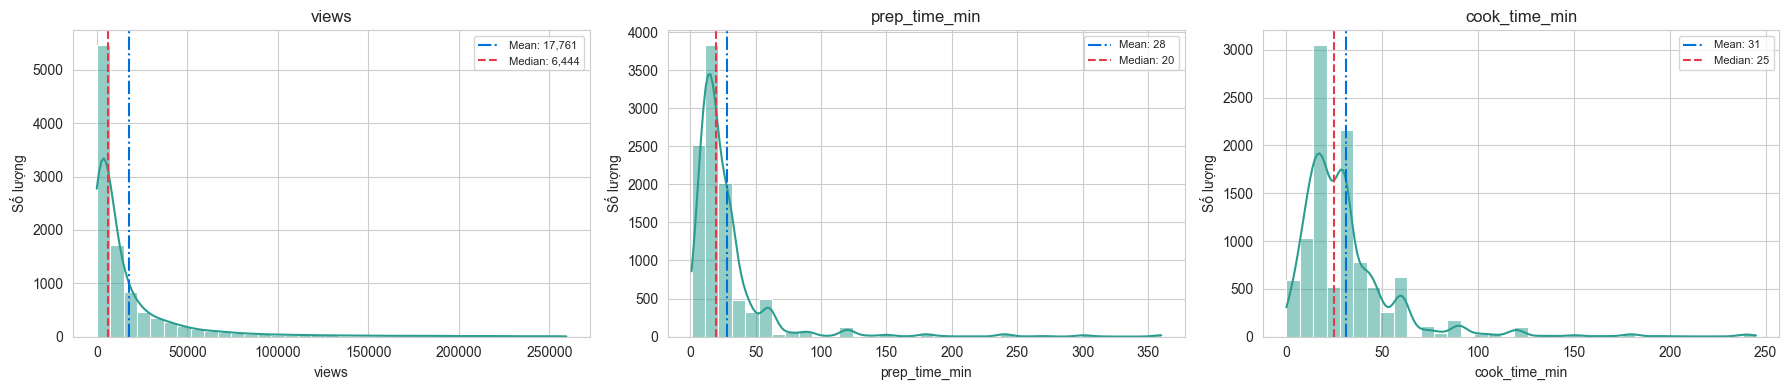

In [6]:
# Mục tiêu: thể hiện phân bố "điển hình" và mức độ lệch của các biến số
numeric_cols = df_recipes.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    # 1) Biến rời rạc difficulty -> countplot để thấy tỷ trọng lớp
    if 'difficulty' in df_recipes.columns:
        plt.figure(figsize=(8, 4))
        order = sorted(df_recipes['difficulty'].dropna().unique())
        ax = sns.countplot(data=df_recipes, x='difficulty', order=order, color='#457b9d')
        total = len(df_recipes)
        for p in ax.patches:
            count = int(p.get_height())
            pct = count * 100 / total
            ax.annotate(f'{count} ({pct:.1f}%)',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)
        plt.title('Phân bố mức độ khó (difficulty)')
        plt.xlabel('Mức độ khó')
        plt.ylabel('Số công thức')
        plt.tight_layout()
        plt.show()

    # 2) Biến liên tục lệch mạnh -> cắt ngưỡng 99% để nhìn rõ phần chính của dữ liệu
    cont_cols = [c for c in ['views', 'prep_time_min', 'cook_time_min'] if c in numeric_cols]
    if cont_cols:
        n = len(cont_cols)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
        if n == 1:
            axes = [axes]

        for ax, col in zip(axes, cont_cols):
            s = df_recipes[col].dropna()
            p99 = s.quantile(0.99)
            s_clip = s[s <= p99]
            mean_val = s_clip.mean()
            median_val = s_clip.median()
            p95 = s_clip.quantile(0.95)

            sns.histplot(s_clip, bins=35, kde=True, ax=ax, color='#2a9d8f')
            ax.axvline(mean_val, color="#0071dc", linestyle='-.', linewidth=1.5, label=f'Mean: {mean_val:,.0f}')
            ax.axvline(median_val, color='#e63946', linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.0f}')
            ax.set_title(f'{col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Số lượng')
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
else:
    print('Không có biến số để vẽ biểu đồ phân bố.')

## Phân Bố dữ liệu theo Từng Thuộc Tính

In [7]:
numeric_cols = df_recipes.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    for col in numeric_cols:
        print(f"\n{col}:")
        print(f"  Giá trị nhỏ nhất: {df_recipes[col].min():.2f}")
        print(f"  Giá trị lớn nhất: {df_recipes[col].max():.2f}")
        print(f"  Trung bình: {df_recipes[col].mean():.2f}")
        print(f"  Trung vị: {df_recipes[col].median():.2f}")
        print(f"  Độ lệch chuẩn: {df_recipes[col].std():.2f}")
        
        skewness = df_recipes[col].skew()
        print(f"  Độ skew: {skewness:.2f}")
        if abs(skewness) < 0.5:
            print(f"    -> Phân bố gần như đối xứng")
        elif skewness > 0:
            print(f"    -> Phân bố lệch phải (positive skew)")
        else:
            print(f"    -> Phân bố lệch trái (negative skew)")

object_cols = df_recipes.select_dtypes(include=['object']).columns.tolist()

if object_cols:
    print(f"\n{'=' * 60}")
    print("PHÂN BỐ CÁC BIẾN PHÂN LOẠI")
    print(f"{'=' * 60}")
    
    for col in object_cols:
        if col not in ['ingredients', 'instructions']:
            print(f"\n{col}:")
            try:
                value_counts = df_recipes[col].value_counts(dropna=False)
                print(f"  Số giá trị duy nhất: {df_recipes[col].nunique(dropna=False)}")
                print(f"  Top 5 giá trị phổ biến nhất:")
                for val, count in value_counts.head(5).items():
                    percent = (count / len(df_recipes)) * 100
                    print(f"    - {val}: {count} ({percent:.2f}%)")
            except:
                print(f"  Không thể phân tích cột này")


difficulty:
  Giá trị nhỏ nhất: 1.00
  Giá trị lớn nhất: 3.00
  Trung bình: 1.13
  Trung vị: 1.00
  Độ lệch chuẩn: 0.34
  Độ skew: 2.44
    -> Phân bố lệch phải (positive skew)

views:
  Giá trị nhỏ nhất: 0.00
  Giá trị lớn nhất: 1331941.00
  Trung bình: 21947.90
  Trung vị: 6583.00
  Độ lệch chuẩn: 56173.28
  Độ skew: 8.56
    -> Phân bố lệch phải (positive skew)

prep_time_min:
  Giá trị nhỏ nhất: 1.00
  Giá trị lớn nhất: 1380.00
  Trung bình: 32.95
  Trung vị: 20.00
  Độ lệch chuẩn: 69.43
  Độ skew: 10.00
    -> Phân bố lệch phải (positive skew)

cook_time_min:
  Giá trị nhỏ nhất: 0.00
  Giá trị lớn nhất: 64800.00
  Trung bình: 45.10
  Trung vị: 25.00
  Độ lệch chuẩn: 675.31
  Độ skew: 88.65
    -> Phân bố lệch phải (positive skew)

PHÂN BỐ CÁC BIẾN PHÂN LOẠI

dish_name:
  Số giá trị duy nhất: 10013
  Top 5 giá trị phổ biến nhất:
    - Sốt Teriyaki Nhật Bản: 11 (0.11%)
    - Trân châu đường đen: 7 (0.07%)
    - Kem cheese từ phô mai con bò cười: 6 (0.06%)
    - Trân châu từ bột nếp

PHÂN BỐ CÁC BIẾN PHÂN LOẠI (TOP 10)


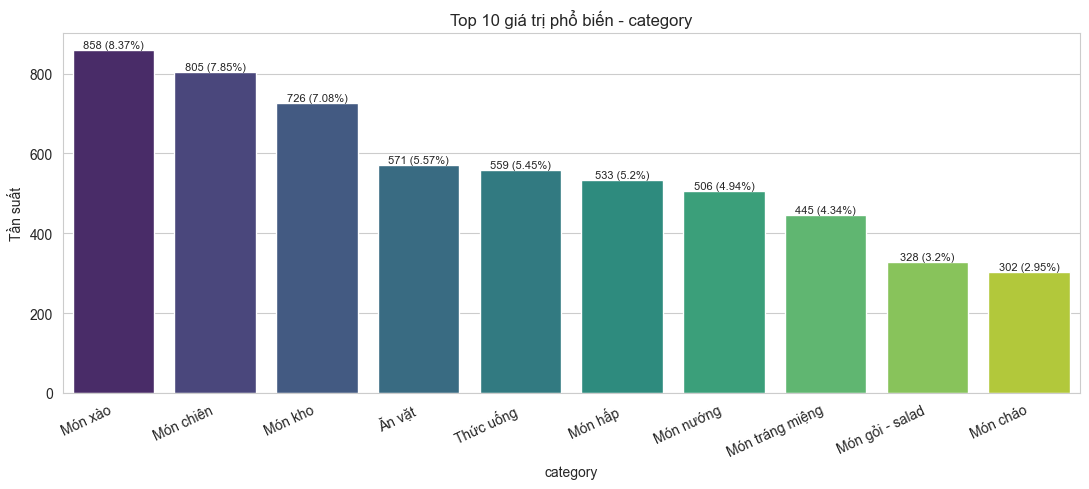

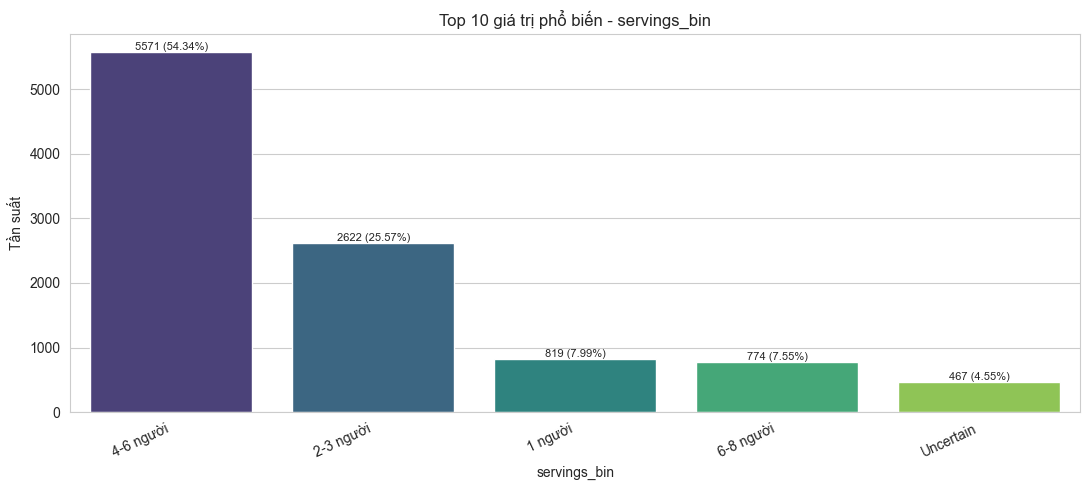

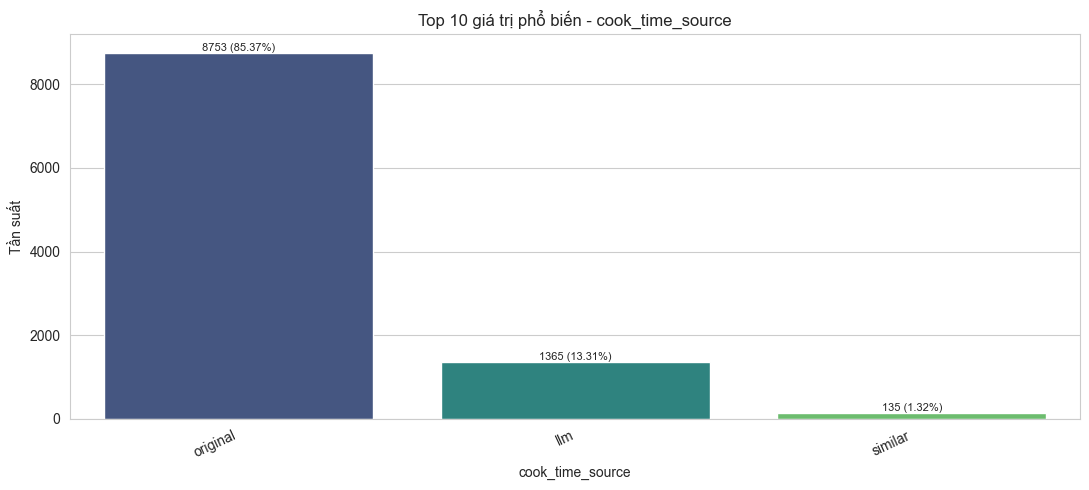

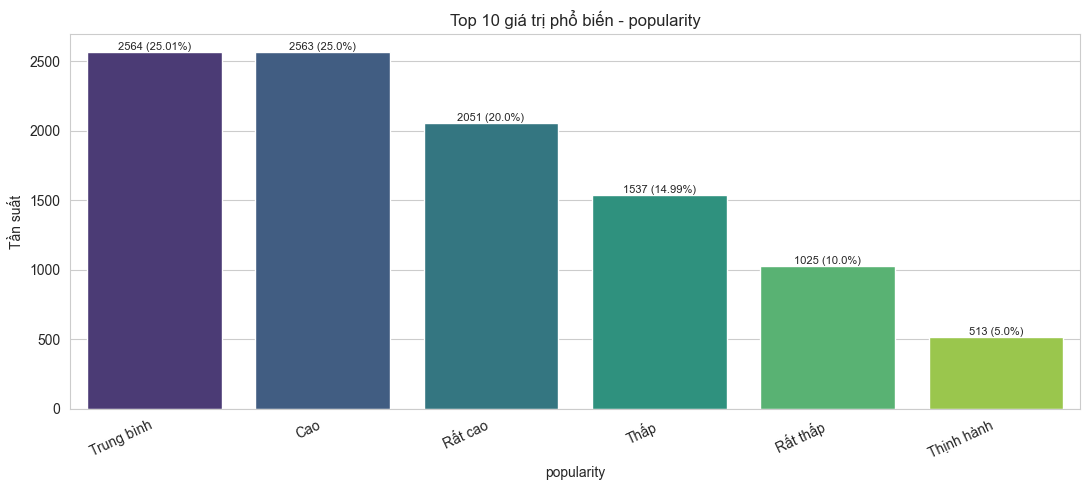

In [8]:
# Plot đồ thị các biến phân loại
object_cols = df_recipes.select_dtypes(include=['object', 'string']).columns.tolist()
candidate_cols = [c for c in object_cols if c not in ['ingredients', 'instructions', 'url', 'dish_name']]

if candidate_cols:
    print('PHÂN BỐ CÁC BIẾN PHÂN LOẠI (TOP 10)')
    for col in candidate_cols:
        vc = df_recipes[col].astype(str).value_counts(dropna=False).head(10)
        pct = (vc / len(df_recipes) * 100).round(2)

        plt.figure(figsize=(11, 5))
        ax = sns.barplot(x=vc.index, y=vc.values, palette='viridis')
        plt.title(f'Top 10 giá trị phổ biến - {col}')
        plt.xlabel(col)
        plt.ylabel('Tần suất')
        plt.xticks(rotation=25, ha='right')

        for i, (count, percent) in enumerate(zip(vc.values, pct.values)):
            ax.text(i, count, f'{count} ({percent}%)', ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.show()
else:
    print('Không có cột phân loại phù hợp để vẽ.')

## Mối Quan Hệ Giữa Độ Khó và Thời Gian Chuẩn Bị
Phân tích xem món ăn khó hơn có cần thời gian chuẩn bị dài hơn hay không.

THỐNG KÊ THỜI GIAN CHUẨN BỊ THEO ĐỘ KHÓ
 difficulty    n       mean  median  q25   q75   p90
          1 8973  28.799287    15.0 10.0  30.0  45.0
          2 1252  60.029553    30.0 20.0  60.0 120.0
          3   28 151.785714    82.5 37.5 120.0 276.0


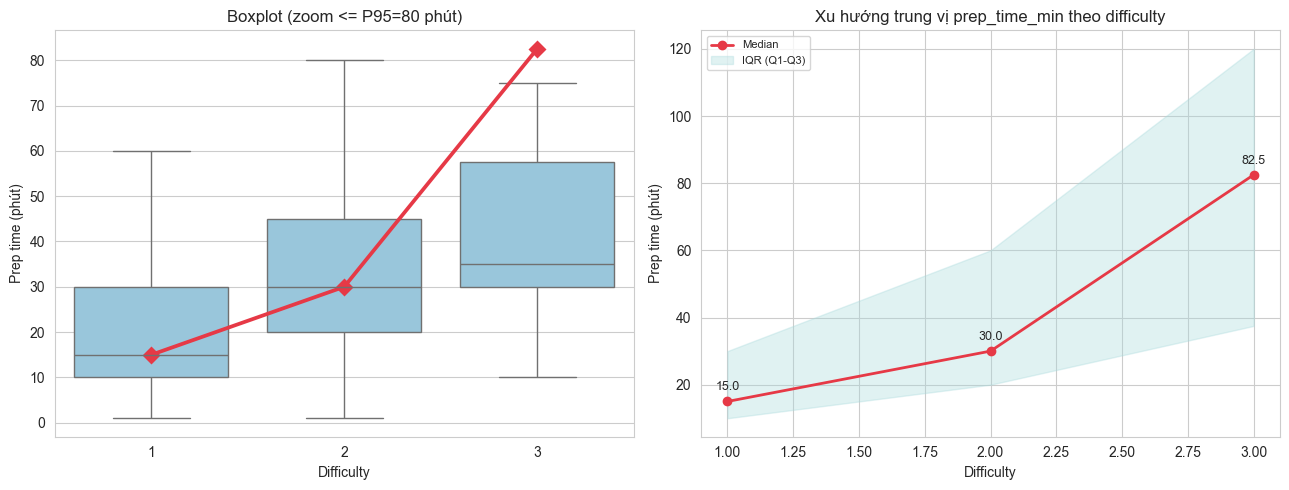


Spearman corr(difficulty, prep_time_min): 0.253
=> Mối quan hệ yếu.

Ghi chú: Biểu đồ đã zoom trong vùng <= P95 (80 phút) để dễ đọc.
Outlier vẫn được phản ánh trong bảng thống kê và hệ số tương quan.


In [9]:
# EDA: Quan hệ giữa độ khó và thời gian chuẩn bị (phiên bản dễ nhìn hơn)
if 'difficulty' in df_recipes.columns and 'prep_time_min' in df_recipes.columns:
    rel_df = df_recipes[['difficulty', 'prep_time_min']].dropna().copy()
    rel_df = rel_df[rel_df['prep_time_min'] >= 0]

    summary = rel_df.groupby('difficulty')['prep_time_min'].agg(
        n='count',
        mean='mean',
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90)
    ).reset_index().sort_values('difficulty')

    print('THỐNG KÊ THỜI GIAN CHUẨN BỊ THEO ĐỘ KHÓ')
    print(summary.to_string(index=False))

    # Dùng ngưỡng P95 để tạo phiên bản zoom dễ nhìn
    y_cap = rel_df['prep_time_min'].quantile(0.95)
    rel_zoom = rel_df[rel_df['prep_time_min'] <= y_cap].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # (1) Boxplot zoom (ẩn outlier) để đọc phân bố chính
    sns.boxplot(data=rel_zoom, x='difficulty', y='prep_time_min', ax=axes[0],
                color='#8ecae6', showfliers=False)
    sns.pointplot(data=summary, x='difficulty', y='median', ax=axes[0],
                  color='#e63946', markers='D', linestyles='-', errorbar=None)
    axes[0].set_title(f'Boxplot (zoom <= P95={y_cap:.0f} phút)')
    axes[0].set_xlabel('Difficulty')
    axes[0].set_ylabel('Prep time (phút)')

    # (2) Xu hướng trung vị + Q1/Q3
    axes[1].plot(summary['difficulty'], summary['median'], marker='o', linewidth=2, color='#e63946', label='Median')
    axes[1].fill_between(summary['difficulty'], summary['q25'], summary['q75'],
                         color='#a8dadc', alpha=0.35, label='IQR (Q1-Q3)')
    for _, row in summary.iterrows():
        axes[1].annotate(f"{row['median']:.1f}", (row['difficulty'], row['median']),
                         textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
    axes[1].set_title('Xu hướng trung vị prep_time_min theo difficulty')
    axes[1].set_xlabel('Difficulty')
    axes[1].set_ylabel('Prep time (phút)')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Tương quan Spearman phù hợp cho biến thứ bậc
    spearman_corr = rel_df['difficulty'].corr(rel_df['prep_time_min'], method='spearman')
    print(f"\nSpearman corr(difficulty, prep_time_min): {spearman_corr:.3f}")
    if abs(spearman_corr) < 0.1:
        print('=> Mối quan hệ rất yếu.')
    elif abs(spearman_corr) < 0.3:
        print('=> Mối quan hệ yếu.')
    elif abs(spearman_corr) < 0.5:
        print('=> Mối quan hệ mức trung bình.')
    else:
        print('=> Mối quan hệ khá mạnh.')

    print(f"\nGhi chú: Biểu đồ đã zoom trong vùng <= P95 ({y_cap:.0f} phút) để dễ đọc.")
    print('Outlier vẫn được phản ánh trong bảng thống kê và hệ số tương quan.')
else:
    print("Thiếu cột 'difficulty' hoặc 'prep_time_min' để phân tích.")

## Phân Tích Phân Bố Nhãn

In [10]:
print("\n" + "=" * 60)
print("PHÂN TÍCH PHÂN BỐ NHÃN")
print("=" * 60)

object_cols = df_recipes.select_dtypes(include=['object']).columns.tolist()

if object_cols:
    for col in object_cols:
        if col not in ['dish_name','url','ingredients', 'instructions']:
            print(f"\n{col}:")
            try:
                value_counts = df_recipes[col].value_counts(dropna=False)
                print(f"  Tổng số lớp/nhãn: {len(value_counts)}")
                print(f"  Phân bố các nhãn:")
                
                for val, count in value_counts.items():
                    percent = (count / len(df_recipes)) * 100
                    try:
                        if pd.isna(val):
                            print(f"    - Missing/NaN: {count} ({percent:.2f}%)")
                        else:
                            print(f"    - {val}: {count} ({percent:.2f}%)")
                    except:
                        print(f"    - {str(val)[:50]}: {count} ({percent:.2f}%)")
                
                if len(value_counts) > 1:
                    max_count = value_counts.max()
                    min_count = value_counts.min()
                    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
                    print(f"\n  Tỉ lệ mất cân bằng (max/min): {imbalance_ratio:.2f}")
                    
                    if imbalance_ratio > 5:
                        print(f"    -> Dữ liệu BỊ MẤT CÂN BẰNG NGHIÊM TRỌNG")
                    elif imbalance_ratio > 2:
                        print(f"    -> Dữ liệu CÓ DẤU HIỆU MẤT CÂN BẰNG")
                    else:
                        print(f"    -> Dữ liệu CÂN BẰNG TỪ TỰC")
            except Exception as e:
                print(f"  Lỗi phân tích: {str(e)}")


PHÂN TÍCH PHÂN BỐ NHÃN

category:
  Tổng số lớp/nhãn: 245
  Phân bố các nhãn:
    - Món xào: 858 (8.37%)
    - Món chiên: 805 (7.85%)
    - Món kho: 726 (7.08%)
    - Ăn vặt: 571 (5.57%)
    - Thức uống: 559 (5.45%)
    - Món hấp: 533 (5.20%)
    - Món nướng: 506 (4.94%)
    - Món tráng miệng: 445 (4.34%)
    - Món gỏi - salad: 328 (3.20%)
    - Món cháo: 302 (2.95%)
    - Ngày lễ Tết: 302 (2.95%)
    - Món chay: 289 (2.82%)
    - ['Món chiên', 'Ăn vặt']: 241 (2.35%)
    - ['Ăn vặt', 'Món tráng miệng']: 219 (2.14%)
    - Món lẩu: 187 (1.82%)
    - Món từ bò: 164 (1.60%)
    - Món từ gà: 151 (1.47%)
    - ['Món xào', 'Món từ bò']: 146 (1.42%)
    - Món cuốn - trộn: 137 (1.34%)
    - ['Ăn vặt', 'Ngày lễ Tết']: 135 (1.32%)
    - Món khô - mắm: 127 (1.24%)
    - ['Món xào', 'Món chay']: 107 (1.04%)
    - ['Thức uống', 'Nước ép']: 100 (0.98%)
    - ['Thức uống', 'Sinh tố']: 94 (0.92%)
    - ['Món xào', 'Món từ gà']: 86 (0.84%)
    - ['Món chiên', 'Món từ gà']: 80 (0.78%)
    - ['Món kho', 

## Phân Tích Nguyên Liệu và Món Ăn

In [11]:
print("\n" + "=" * 60)
print("PHÂN TÍCH NGUYÊN LIỆU")
print("=" * 60)

print(f"\nTổng số nguyên liệu duy nhất: {len(unique_ingredients)}")
print(f"Kiểu dữ liệu: {type(unique_ingredients)}")
if isinstance(unique_ingredients, list) and len(unique_ingredients) > 0:
    print(f"\n10 nguyên liệu đầu tiên:")
    for i, ingredient in enumerate(unique_ingredients[:10], 1):
        print(f"  {i}. {ingredient}")

print(f"\n{'=' * 60}")
print("PHÂN TÍCH MÓN ĂN")
print("=" * 60)

print(f"\nTổng số món ăn duy nhất: {len(unique_dishes)}")
print(f"Kiểu dữ liệu: {type(unique_dishes)}")

if isinstance(unique_dishes, list) and len(unique_dishes) > 0:
    print(f"\n10 món ăn đầu tiên:")
    for i, dish in enumerate(unique_dishes[:10], 1):
        print(f"  {i}. {dish}")


PHÂN TÍCH NGUYÊN LIỆU

Tổng số nguyên liệu duy nhất: 7947
Kiểu dữ liệu: <class 'list'>

10 nguyên liệu đầu tiên:
  1. nước mắm
  2. 1 bột ngọt
  3. 1 củ gừng
  4. 1 củ hành tây
  5. 1 gói
  6. 1 muỗng canh mắm tép hàn quốc
  7. 1 muỗng cà phê hành lá băm
  8. 1 muỗng cà phê hạt cà phê hoặc cà phê xay
  9. 1 muỗng cà phê tiêu đen nguyên hạt
  10. 1 muỗng cà phê ớt bột hàn quốc

PHÂN TÍCH MÓN ĂN

Tổng số món ăn duy nhất: 10012
Kiểu dữ liệu: <class 'list'>

10 món ăn đầu tiên:
  1. Cơm chiên bò xào
  2. Gỏi trái điều thịt heo
  3. Bánh mì sandwich trứng chiên xúc xích
  4. Bí nụ xào tỏi
  5. Sò lụa xào me
  6. Thạch chanh dây
  7. Nem hải sản sốt mayonnaise
  8. Cá nhám kho nghệ
  9. Nấm rơm kho tương hột đậu hũ
  10. Mận ngâm đường phèn


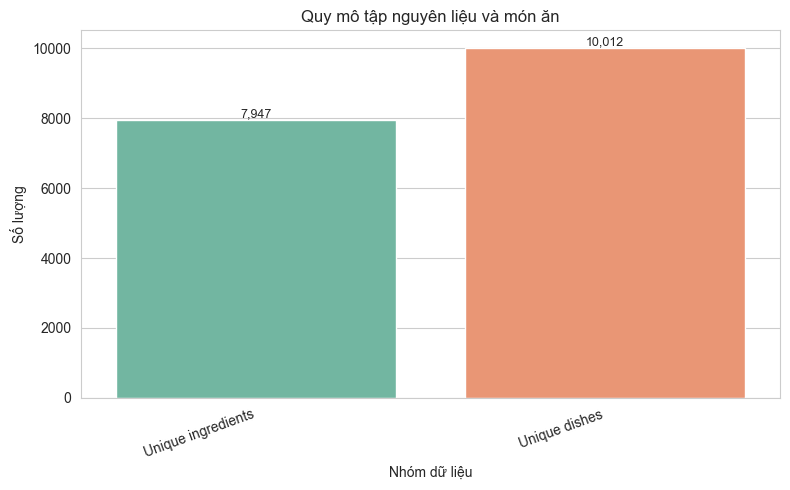

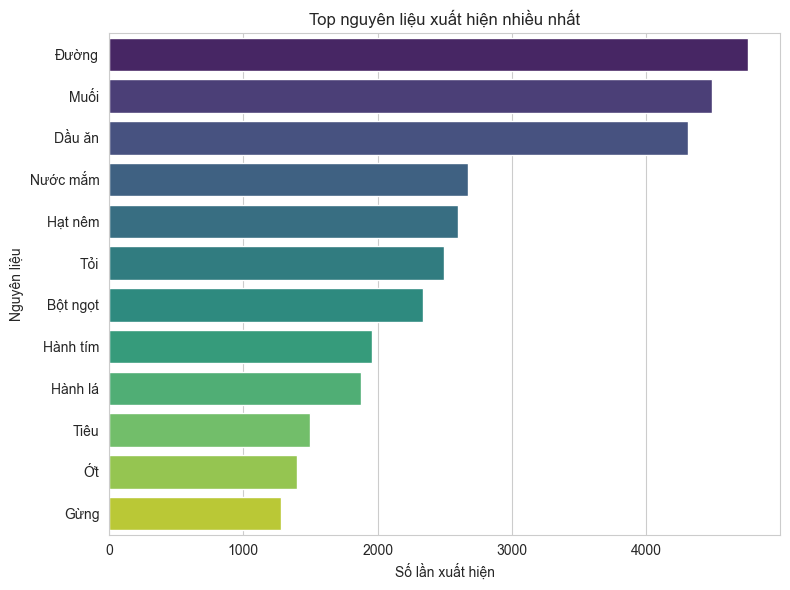

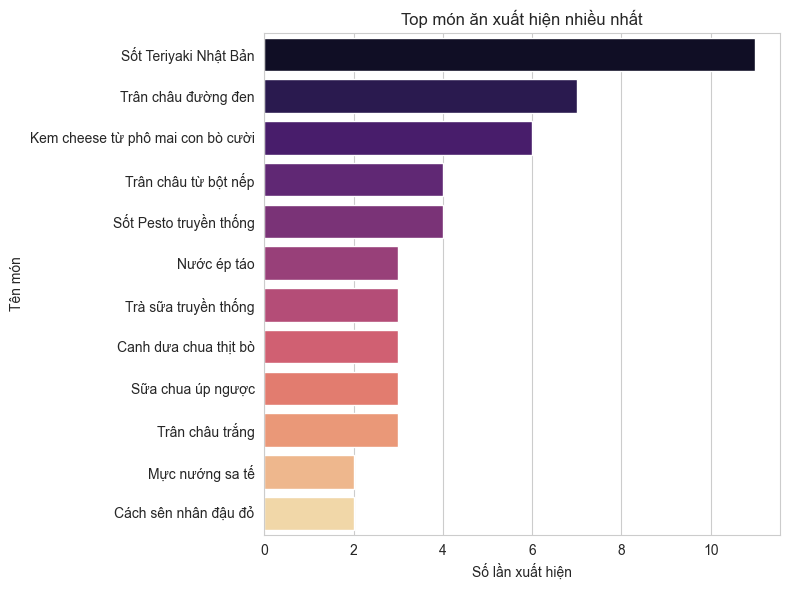

In [12]:
# Biểu đồ cho phân tích nguyên liệu và món ăn (mỗi biểu đồ 1x1)
entity_sizes = pd.Series({
    'Unique ingredients': len(unique_ingredients),
    'Unique dishes': len(unique_dishes),
    
})

# (1) Quy mô tổng quan
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=entity_sizes.index, y=entity_sizes.values, palette='Set2')
plt.title('Quy mô tập nguyên liệu và món ăn')
plt.xlabel('Nhóm dữ liệu')
plt.ylabel('Số lượng')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(entity_sizes.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Hàm tách tên nguyên liệu từ nhiều định dạng khác nhau
def extract_ingredient_names(x):
    names = []
    if isinstance(x, list):
        for item in x:
            if isinstance(item, dict):
                for key in ['ingredient', 'name', 'ingredient_name', 'item']:
                    if key in item and item[key]:
                        names.append(str(item[key]).strip())
                        break
            elif isinstance(item, str):
                t = item.strip()
                if t:
                    names.append(t)
    elif isinstance(x, str):
        t = x.strip()
        if t:
            try:
                parsed = json.loads(t)
                return extract_ingredient_names(parsed)
            except Exception:
                names.extend([p.strip() for p in t.split(',') if p.strip()])
    return names

# (2) Top nguyên liệu xuất hiện trong công thức
ingredient_counter = Counter()
for val in df_recipes.get('ingredients', pd.Series(dtype='object')).dropna():
    ingredient_counter.update(extract_ingredient_names(val))

top_ing = pd.Series(dict(ingredient_counter.most_common(12)))
if len(top_ing) > 0:
    plt.figure(figsize=(8, 6))
    sns.barplot(y=top_ing.index, x=top_ing.values, palette='viridis')
    plt.title('Top nguyên liệu xuất hiện nhiều nhất')
    plt.xlabel('Số lần xuất hiện')
    plt.ylabel('Nguyên liệu')
    plt.tight_layout()
    plt.show()
else:
    print('Không đọc được dữ liệu nguyên liệu để vẽ biểu đồ top nguyên liệu.')

# (3) Top món ăn lặp lại trong dữ liệu
dish_counts = df_recipes['dish_name'].astype(str).value_counts().head(12)
plt.figure(figsize=(8, 6))
sns.barplot(y=dish_counts.index, x=dish_counts.values, palette='magma')
plt.title('Top món ăn xuất hiện nhiều nhất')
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Tên món')
plt.tight_layout()
plt.show()

## Phân Tích Chi Tiết Công Thức

In [13]:
print("\n" + "=" * 60)
print("PHÂN TÍCH CHI TIẾT CÔNG THỨC NẤU ĂN")
print("=" * 60)

if df_recipes is not None and len(df_recipes) > 0:
    print(f"\nTổng số công thức: {len(df_recipes)}")
    
    print(f"\nCác trường dữ liệu trong mỗi công thức:")
    for i, col in enumerate(df_recipes.columns, 1):
        print(f"  {i}. {col}")
    
    print(f"\nKích thước DataFrame:")
    print(f"  - Hàng: {df_recipes.shape[0]}")
    print(f"  - Cột: {df_recipes.shape[1]}")
    
    # Hiển thị mẫu dữ liệu
    print(f"\nMột số dòng dữ liệu mẫu (3 dòng đầu):")
    print(df_recipes.head(3).to_string())


PHÂN TÍCH CHI TIẾT CÔNG THỨC NẤU ĂN

Tổng số công thức: 10253

Các trường dữ liệu trong mỗi công thức:
  1. dish_name
  2. url
  3. difficulty
  4. views
  5. ingredients
  6. instructions
  7. category
  8. prep_time_min
  9. cook_time_min
  10. servings_bin
  11. cook_time_source
  12. popularity

Kích thước DataFrame:
  - Hàng: 10253
  - Cột: 12

Một số dòng dữ liệu mẫu (3 dòng đầu):
                dish_name                                                                                                     url  difficulty  views                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## Tóm Tắt Kết Quả EDA

In [14]:
print("\n1. TỔNG QUAN:")
print(f"   • Tập dữ liệu công thức: {df_recipes.shape[0]} hàng x {df_recipes.shape[1]} cột")
print(f"   • Số món ăn duy nhất: {len(unique_dishes)}")
print(f"   • Số nguyên liệu duy nhất: {len(unique_ingredients)}")

missing_percent = (df_recipes.isnull().sum() / len(df_recipes) * 100).max()
print(f"   • Tỉ lệ dữ liệu thiếu tối đa: {missing_percent:.2f}%")

print("\n2. BIẾN SỐ:")
numeric_cols = df_recipes.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(f"   • Số biến số: {len(numeric_cols)}")
    for col in numeric_cols:
        print(f"     - {col}: mean={df_recipes[col].mean():.2f}, "
              f"std={df_recipes[col].std():.2f}, "
              f"min={df_recipes[col].min():.2f}, max={df_recipes[col].max():.2f}")
else:
    print("   • Không có biến số trong dữ liệu công thức")

print("\n3. BIẾN PHÂN LOẠI:")
object_cols = df_recipes.select_dtypes(include=['object']).columns.tolist()
printable_cols = [col for col in object_cols if col not in ['ingredients', 'instructions']]
if printable_cols:
    print(f"   • Số biến phân loại (có thể phân tích): {len(printable_cols)}")
    for col in printable_cols:
        try:
            n_unique = df_recipes[col].nunique(dropna=False)
            print(f"     - {col}: {n_unique} giá trị duy nhất")
        except:
            print(f"     - {col}: Không thể tính")
else:
    print("   • Không có biến phân loại")

print("\n4. CÂN BẰNG DỮ LIỆU (theo Độ khó và Danh mục):")
for col in ['difficulty', 'category']:
    if col in df_recipes.columns:
        try:
            value_counts = df_recipes[col].value_counts(dropna=False)
            if len(value_counts) > 1:
                max_count = value_counts.max()
                min_count = value_counts.min()
                imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
                status = "CÂN BẰNG" if imbalance_ratio < 2 else "MẤT CÂN BẰNG" if imbalance_ratio < 5 else "MẤT CÂN BẰNG NGHIÊM TRỌNG"
                print(f"   • {col}: {status} (Tỉ lệ {imbalance_ratio:.2f})")
        except:
            pass

print("\n5. ĐẶC ĐIỂM DỮ LIỆU CÔNG THỨC:")
print(f"   • Tình trạng dữ liệu:")
print(f"     - Tổng hàng: {len(df_recipes)}")
print(f"     - Tổng cột: {len(df_recipes.columns)}")
print(f"     - Kiểu dữ liệu: {df_recipes.dtypes.value_counts().to_dict()}")


1. TỔNG QUAN:
   • Tập dữ liệu công thức: 10253 hàng x 12 cột
   • Số món ăn duy nhất: 10012
   • Số nguyên liệu duy nhất: 7947
   • Tỉ lệ dữ liệu thiếu tối đa: 0.00%

2. BIẾN SỐ:
   • Số biến số: 4
     - difficulty: mean=1.13, std=0.34, min=1.00, max=3.00
     - views: mean=21947.90, std=56173.28, min=0.00, max=1331941.00
     - prep_time_min: mean=32.95, std=69.43, min=1.00, max=1380.00
     - cook_time_min: mean=45.10, std=675.31, min=0.00, max=64800.00

3. BIẾN PHÂN LOẠI:
   • Số biến phân loại (có thể phân tích): 6
     - dish_name: 10013 giá trị duy nhất
     - url: 10253 giá trị duy nhất
     - category: Không thể tính
     - servings_bin: 5 giá trị duy nhất
     - cook_time_source: 3 giá trị duy nhất
     - popularity: 6 giá trị duy nhất

4. CÂN BẰNG DỮ LIỆU (theo Độ khó và Danh mục):
   • difficulty: MẤT CÂN BẰNG NGHIÊM TRỌNG (Tỉ lệ 320.46)
   • category: MẤT CÂN BẰNG NGHIÊM TRỌNG (Tỉ lệ 858.00)

5. ĐẶC ĐIỂM DỮ LIỆU CÔNG THỨC:
   • Tình trạng dữ liệu:
     - Tổng hàng: 10253